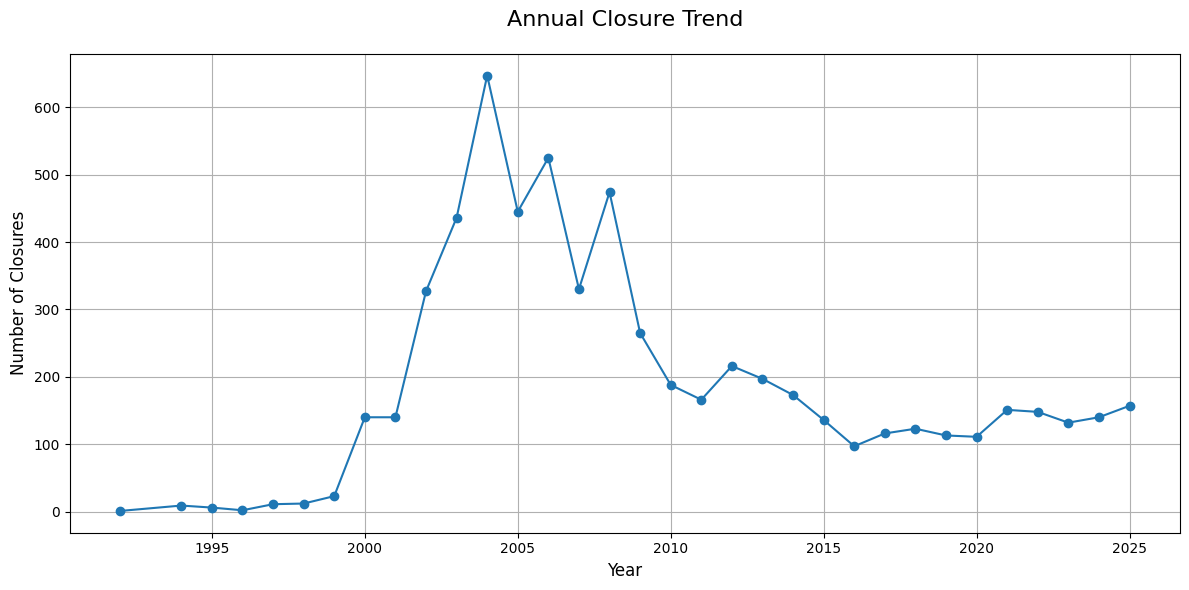

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv('./data_csv/강원특별자치도_식품자동판매기업.csv', encoding='cp949')

# Convert 폐업일자 to datetime
data['폐업일자'] = pd.to_datetime(data['폐업일자'], errors='coerce')

# Extract year
data['폐업연도'] = data['폐업일자'].dt.year

# Count yearly closures
yearly = data['폐업연도'].dropna().value_counts().sort_index()

# Plot (no Korean text)
plt.figure(figsize=(12, 6))
plt.plot(yearly.index, yearly.values, marker='o')

plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Closures", fontsize=12)
plt.title("Annual Closure Trend", fontsize=16, pad=20)

plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 한글 폰트 설정 — 맥북이면 AppleGothic!
plt.rc('font', family='AppleGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [5]:
plt.rc('font', family='NanumGothic')

In [2]:
import pandas as pd

# CSV 불러오기
data = pd.read_csv('./data_csv/강원특별자치도_식품자동판매기업.csv', encoding='cp949')

# 날짜를 datetime 형식으로 변환
data['인허가일자'] = pd.to_datetime(data['인허가일자'], errors='coerce')
data['폐업일자'] = pd.to_datetime(data['폐업일자'], errors='coerce')

# 생존일수 계산 (폐업일 - 인허가일)
data['생존일수'] = (data['폐업일자'] - data['인허가일자']).dt.days

# 폐업한 업체만 필터링
closed = data.dropna(subset=['폐업일자', '생존일수'])

# 통계 요약
summary = {
    "총 폐업 업체 수": len(closed),
    "평균 생존기간(일)": round(closed['생존일수'].mean(), 1),
    "평균 생존기간(년)": round(closed['생존일수'].mean() / 365, 2),
    "중위수 생존기간(일)": float(closed['생존일수'].median()),
    "최소 생존기간(일)": int(closed['생존일수'].min()),
    "최대 생존기간(일)": int(closed['생존일수'].max())
}

summary

{'총 폐업 업체 수': 6147,
 '평균 생존기간(일)': np.float64(2763.6),
 '평균 생존기간(년)': np.float64(7.57),
 '중위수 생존기간(일)': 2233.0,
 '최소 생존기간(일)': 0,
 '최대 생존기간(일)': 13822}